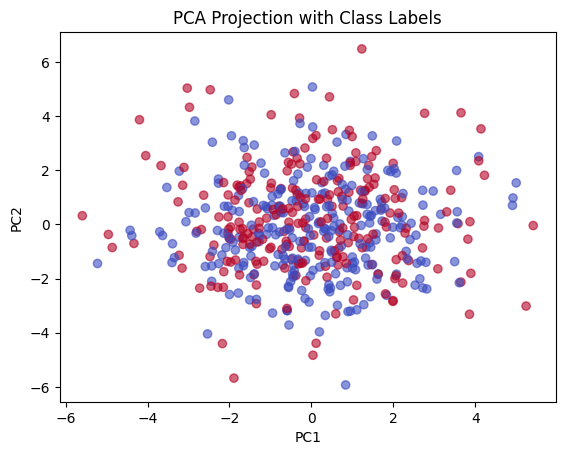

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 模拟数据：500个样本，350个基因
np.random.seed(2037)
n_samples, n_genes = 500, 350
X = np.random.normal(0, 1, (n_samples, n_genes))

# 生成分类标签
logits = (
    X[:,200:230].sum(axis=1)*1.8 +   # EMT模块（正相关）
    X[:,120:150].sum(axis=1)*(-1.5)  # 免疫模块（负相关）
)
prob = 1 / (1 + np.exp(-logits))
relapse = (prob > 0.5).astype(int)
y_clf = relapse.reshape(-1,1)

# 2. 中心化
X_centered = X - X.mean(axis=0)

# 3. 协方差矩阵
cov_matrix = np.cov(X_centered, rowvar=False)  # 350x350

# 4. 特征分解
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

# 5. 排序（按特征值大小）
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]

# 6. 选前2个主成分
W = eig_vecs[:, :2]
X_pca = X_centered @ W  # 500x2

# 可视化
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_clf.ravel(), cmap='coolwarm', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection with Class Labels")
plt.show()


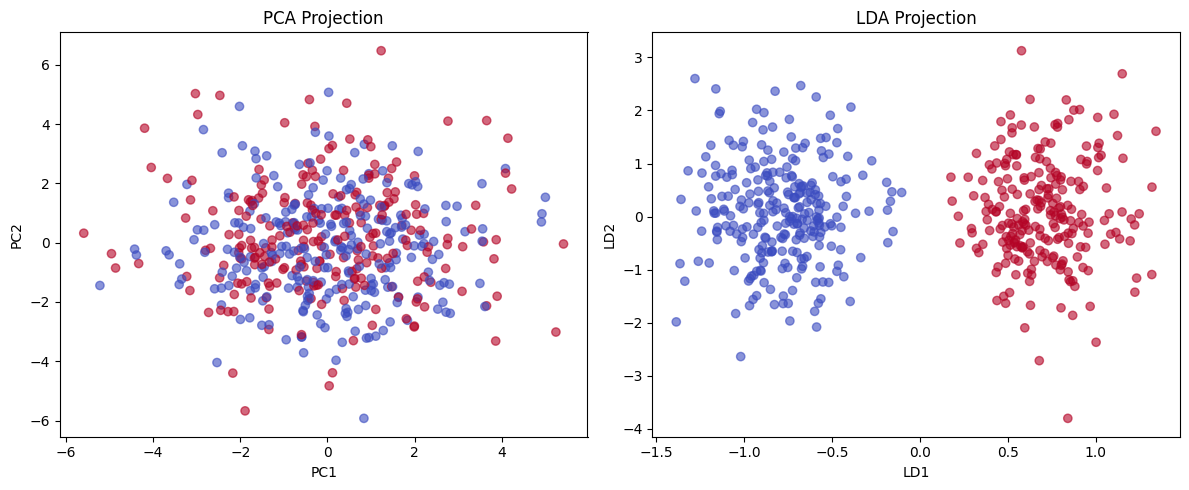

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 模拟数据：500个样本，350个基因
np.random.seed(2037)
n_samples, n_genes = 500, 350
X = np.random.normal(0, 1, (n_samples, n_genes))

# 生成分类标签
logits = (
    X[:,200:230].sum(axis=1)*1.8 +   # EMT模块（正相关）
    X[:,120:150].sum(axis=1)*(-1.5)  # 免疫模块（负相关）
)
prob = 1 / (1 + np.exp(-logits))
relapse = (prob > 0.5).astype(int)
y_clf = relapse.reshape(-1,1)

# ---------------- PCA ----------------
X_centered = X - X.mean(axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)  # 350x350
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, sorted_idx]
W_pca = eig_vecs[:, :2]
X_pca = X_centered @ W_pca  # 500x2

# ---------------- LDA ----------------
X0 = X[y_clf.ravel()==0]
X1 = X[y_clf.ravel()==1]
mean0 = X0.mean(axis=0)
mean1 = X1.mean(axis=0)
overall_mean = X.mean(axis=0)

S_W = np.cov(X0, rowvar=False)*(X0.shape[0]-1) + np.cov(X1, rowvar=False)*(X1.shape[0]-1)
mean_diff0 = (mean0 - overall_mean).reshape(-1,1)
mean_diff1 = (mean1 - overall_mean).reshape(-1,1)
S_B = X0.shape[0] * (mean_diff0 @ mean_diff0.T) + X1.shape[0] * (mean_diff1 @ mean_diff1.T)

eig_vals_lda, eig_vecs_lda = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
sorted_idx_lda = np.argsort(eig_vals_lda)[::-1]
W_lda = eig_vecs_lda[:, sorted_idx_lda[:2]].real
X_lda = X @ W_lda

# ---------------- 可视化 ----------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PCA 图
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y_clf.ravel(), cmap='coolwarm', alpha=0.6)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Projection")

# LDA 图
axes[1].scatter(X_lda[:,0], X_lda[:,1], c=y_clf.ravel(), cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].set_title("LDA Projection")

plt.tight_layout()
plt.show()


回归系数 β: [0.63141536 0.24797603 0.66747696]
R^2: 0.0112075905350143
梯度下降求解的参数 θ: [0.45543486 0.20788896 0.49745947]


Text(0.5, 1.0, 'Gradient Descent Loss Curve')

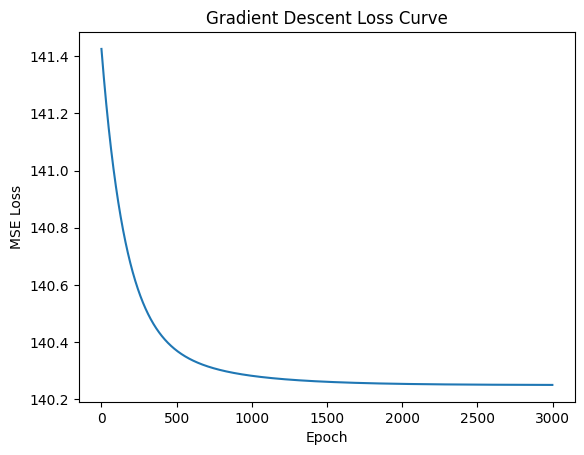

In [ ]:
import numpy as np

# 假设我们已有 PCA 的结果 X_pca (500x2)
# 生成一个连续目标变量：生存时间
y_survival = (
    X[:,0:20].sum(axis=1)*2.0 +   # DNA修复模块
    X[:,50:70].sum(axis=1)*1.5 +  # 细胞周期模块
    np.random.normal(0, 5, n_samples)  # 噪声
)

# 1. 添加截距项 (常数1列)
X_design = np.hstack([np.ones((n_samples,1)), X_pca])  # 500x3

# 2. 正规方程解 β = (X^T X)^(-1) X^T y
XtX = X_design.T @ X_design
XtX_inv = np.linalg.inv(XtX)
XtY = X_design.T @ y_survival
beta = XtX_inv @ XtY   # 回归系数 (截距 + 每个主成分的系数)

# 3. 预测值
y_pred = X_design @ beta

# 4. 计算 R^2
SS_res = np.sum((y_survival - y_pred)**2)
SS_tot = np.sum((y_survival - y_survival.mean())**2)
R2 = 1 - SS_res/SS_tot

print("回归系数 β:", beta)
print("R^2:", R2)



# 梯度下降求解
# 用 PCA 的结果作为输入特征 
X_lin = X_pca # 500x2 
m, n = X_lin.shape

# 生成一个连续目标变量 y_reg 
y_reg = ( X[:,0:20].sum(axis=1)*2.0 +
          X[:,50:70].sum(axis=1)*1.5 + 
          np.random.normal(0, 5, m) ).reshape(-1,1)

# 初始化参数
theta = np.zeros((n+1,1))  # 包含截距项
X_design = np.hstack([np.ones((m,1)), X_lin])  # 添加截距项
lr = 0.001  # 学习率
epochs = 3000
losses = []
for epoch in range(epochs):
    y_pred = X_design @ theta
    error = y_pred - y_reg
    grad = (X_design.T @ error) / m
    theta -= lr * grad  
    loss = np.mean(error**2)
    losses.append(loss)
print("梯度下降求解的参数 θ:", theta.ravel())
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Loss Curve")


# 逻辑回归
sigmoid = lambda z: 1 / (1 + np.exp(-z))
X_logistic = X_pca  # 500x2
m, n = X_logistic.shape
y_logistic = y_clf  # 500x1
theta_logistic = np.zeros((n+1,1))  # 包含截距项
X_design_logistic = np.hstack([np.ones((m,1)), X_logistic])  # 添加截距项
lr_logistic = 0.01
epochs_logistic = 3000
losses_logistic = []
for epoch in range(epochs_logistic):
    z = X_design_logistic @ theta_logistic
    y_pred_logistic = sigmoid(z)
    error_logistic = y_pred_logistic - y_logistic
    grad_logistic = (X_design_logistic.T @ error_logistic) / m
    theta_logistic -= lr_logistic * grad_logistic  
    loss_logistic = -np.mean(y_logistic * np.log(y_pred_logistic + 1e-8) + 
                             (1 - y_logistic) * np.log(1 - y_pred_logistic + 1e-8))
    losses_logistic.append(loss_logistic)
print("逻辑回归求解的参数 θ:", theta_logistic.ravel())
plt.plot(losses_logistic)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Logistic Regression Loss Curve")